# Number of Orders Prediction

## Objective
To build a machine learning model that predicts the number of customer orders based on historical data. This helps businesses forecast demand, optimize inventory, and improve decision-making.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

## Load Dataset
We load the dataset containing historical order data.

In [5]:
orders = pd.read_csv("orders.csv")
order_products = pd.read_csv("order_products__train.csv")

orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


## Merge Datasets
We merge order-level and product-level data using order_id.

In [6]:
df = pd.merge(order_products, orders, on='order_id')
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,112108,train,4,4,10,9.0
1,1,11109,2,1,112108,train,4,4,10,9.0
2,1,10246,3,0,112108,train,4,4,10,9.0
3,1,49683,4,0,112108,train,4,4,10,9.0
4,1,43633,5,1,112108,train,4,4,10,9.0


In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1384617 non-null  int64  
 1   product_id              1384617 non-null  int64  
 2   add_to_cart_order       1384617 non-null  int64  
 3   reordered               1384617 non-null  int64  
 4   user_id                 1384617 non-null  int64  
 5   eval_set                1384617 non-null  object 
 6   order_number            1384617 non-null  int64  
 7   order_dow               1384617 non-null  int64  
 8   order_hour_of_day       1384617 non-null  int64  
 9   days_since_prior_order  1384617 non-null  float64
dtypes: float64(1), int64(8), object(1)
memory usage: 105.6+ MB


order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

## Data Preprocessing
- Handle missing values  
- Convert features  

In [9]:
# Fill missing values
df['days_since_prior_order'].fillna(0, inplace=True)

## Improved Feature Engineering

Instead of aggregating by day of week (which gives only 7 rows),  
we create a dataset where each row represents an individual order.

This allows us to:
- Keep thousands of samples  
- Train a proper ML model  

In [12]:
# Count number of products in each order
order_size = df.groupby('order_id').size().reset_index(name='num_products')

# Merge back with orders dataset
final_df = pd.merge(order_size, orders, on='order_id')

final_df.head()

,order_id,num_products,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,8,112108,train,4,4,10,9.0
1,36,8,79431,train,23,6,18,30.0
2,38,9,42756,train,6,6,16,24.0
3,96,7,17227,train,7,6,20,30.0
4,98,49,56463,train,41,3,8,14.0


In [13]:
# Fill missing values
final_df['days_since_prior_order'].fillna(0, inplace=True)

# Features
final_df['is_weekend'] = final_df['order_dow'].apply(lambda x: 1 if x >= 5 else 0)

final_df.head()

,order_id,num_products,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_weekend
0,1,8,112108,train,4,4,10,9.0,0
1,36,8,79431,train,23,6,18,30.0,1
2,38,9,42756,train,6,6,16,24.0,1
3,96,7,17227,train,7,6,20,30.0,1
4,98,49,56463,train,41,3,8,14.0,0


## Advanced Feature Engineering & Modeling

To improve model performance and realism, we:
- Create user-level behavioral features
- Add lag-style features using prior orders
- Capture temporal patterns (hour, weekday, recency)
- Use XGBoost with tuned parameters

This transforms the problem into a more realistic demand prediction system.

In [15]:
# Order size (target base)
order_size = df.groupby('order_id').size().reset_index(name='num_products')

# Merge with orders
final_df = pd.merge(order_size, orders, on='order_id')

# Fill missing values
final_df['days_since_prior_order'].fillna(0, inplace=True)

# Sort for proper lag creation
final_df = final_df.sort_values(['user_id', 'order_number'])

In [16]:
# Previous order size (lag feature)
final_df['prev_order_size'] = final_df.groupby('user_id')['num_products'].shift(1)

# Rolling mean of last 3 orders
final_df['rolling_avg_3'] = final_df.groupby('user_id')['num_products'].rolling(3).mean().reset_index(0, drop=True)

# Fill lag NaNs
final_df.fillna(0, inplace=True)

In [17]:
# Total orders per user
user_total_orders = final_df.groupby('user_id')['order_number'].transform('max')

# Average order size per user
user_avg_size = final_df.groupby('user_id')['num_products'].transform('mean')

final_df['user_total_orders'] = user_total_orders
final_df['user_avg_order_size'] = user_avg_size

In [18]:
# Weekend feature
final_df['is_weekend'] = final_df['order_dow'].apply(lambda x: 1 if x >= 5 else 0)

# Peak hour feature
final_df['is_peak_hour'] = final_df['order_hour_of_day'].apply(lambda x: 1 if 10 <= x <= 18 else 0)

In [38]:
features = [
    'order_dow',
    'order_hour_of_day',
    'days_since_prior_order',
    'prev_order_size',
    'user_total_orders',
    'is_weekend',
    'is_peak_hour'
]

X = final_df[features]
y = final_df['num_products']

## Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:
- Distribution of order sizes
- Temporal patterns (day, hour)
- User behavior trends
- Relationships between features

This helps validate assumptions and improve feature selection.

In [21]:
final_df.head()

,order_id,num_products,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,prev_order_size,rolling_avg_3,user_total_orders,user_avg_order_size,is_weekend,is_peak_hour
45974,1187899,11,1,train,11,4,8,14.0,0.0,0.0,11,11.0,0,0
57713,1492625,31,2,train,15,1,11,30.0,0.0,0.0,15,31.0,0,1
84605,2196797,9,5,train,5,0,11,6.0,0.0,0.0,5,9.0,0,1
20273,525192,9,7,train,21,2,11,6.0,0.0,0.0,21,9.0,0,1
34209,880375,18,8,train,4,1,14,10.0,0.0,0.0,4,18.0,0,1


In [22]:
final_df.describe()

,order_id,num_products,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,prev_order_size,rolling_avg_3,user_total_orders,user_avg_order_size,is_weekend,is_peak_hour
count,1.312090e+05,131209.000000,131209.000000,131209.000000,131209.000000,131209.000000,131209.000000,131209.0,131209.0,131209.000000,131209.000000,131209.000000,131209.000000
mean,1.704050e+06,10.552759,103166.825317,16.603937,2.768431,13.581363,17.049859,0.0,0.0,16.603937,10.552759,0.276711,0.702025
std,9.889077e+05,7.932847,59565.307804,16.661077,2.121701,4.221325,10.676832,0.0,0.0,16.661077,7.932847,0.447374,0.457370
min,1.000000e+00,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.0,0.0,4.000000,1.000000,0.000000,0.000000
25%,8.451640e+05,5.000000,51587.000000,6.000000,1.000000,10.000000,7.000000,0.0,0.0,6.000000,5.000000,0.000000,0.000000
50%,1.696847e+06,9.000000,103150.000000,10.000000,3.000000,14.000000,15.000000,0.0,0.0,10.000000,9.000000,0.000000,1.000000
75%,2.561480e+06,14.000000,154868.000000,20.000000,5.000000,17.000000,30.000000,0.0,0.0,20.000000,14.000000,1.000000,1.000000
max,3.421070e+06,80.000000,206209.000000,100.000000,6.000000,23.000000,30.000000,0.0,0.0,100.000000,80.000000,1.000000,1.000000


## Distribution of Order Size

Understanding how many products are typically ordered.

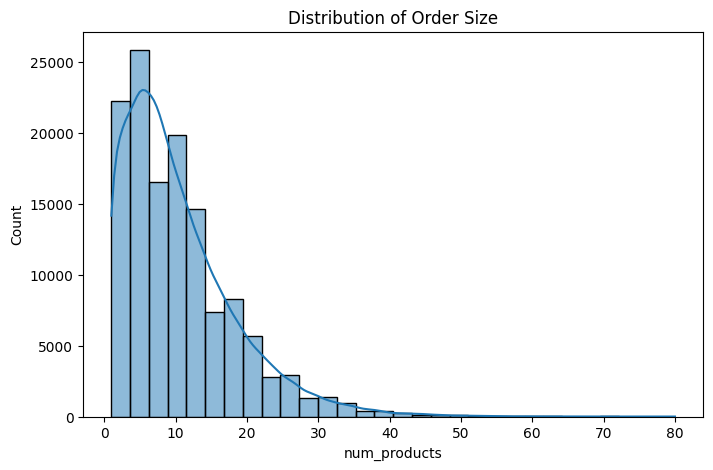

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(final_df['num_products'], bins=30, kde=True)
plt.title("Distribution of Order Size")
plt.show()

## Orders by Day of Week

Analyzing which days have higher demand.

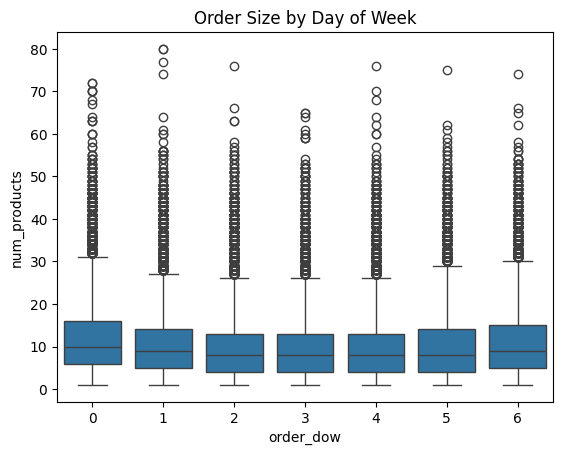

In [25]:
sns.boxplot(x='order_dow', y='num_products', data=final_df)
plt.title("Order Size by Day of Week")
plt.show()

## Orders by Hour

Understanding peak order hours.

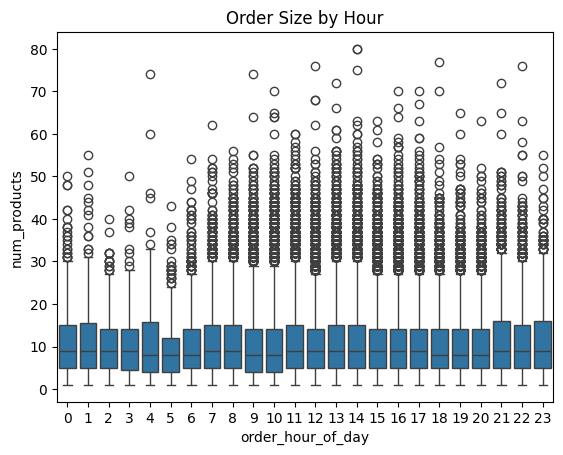

In [26]:
sns.boxplot(x='order_hour_of_day', y='num_products', data=final_df)
plt.title("Order Size by Hour")
plt.show()

## User Behavior

Analyzing how user activity impacts order size.

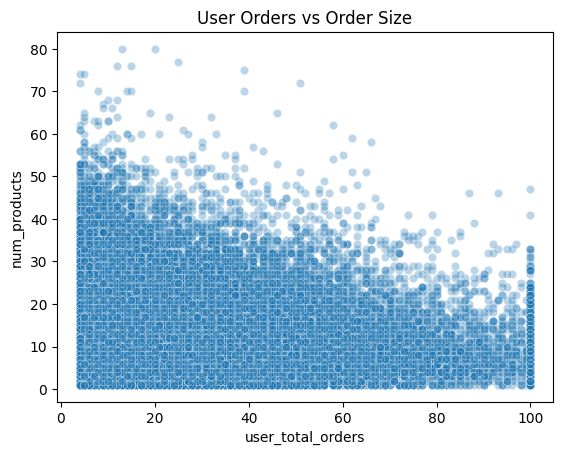

In [27]:
sns.scatterplot(
    x='user_total_orders',
    y='num_products',
    data=final_df,
    alpha=0.3
)
plt.title("User Orders vs Order Size")
plt.show()

## Correlation Analysis

Understanding relationships between numerical features.

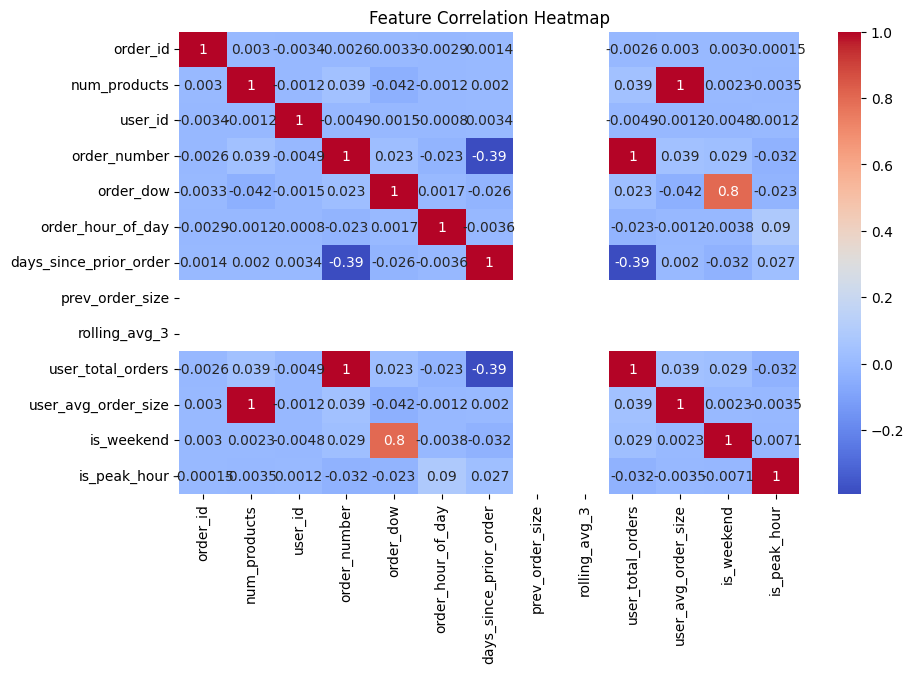

In [31]:
final_df = final_df.drop(columns=['eval_set', ], errors='ignore')

plt.figure(figsize=(10,6))
sns.heatmap(final_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Key Insights from EDA

### 1. Order Size Distribution
- The distribution of `num_products` is right-skewed, indicating that most orders contain a small number of products, while a few orders are significantly larger.
- This suggests the presence of **outliers or bulk buyers**, which may impact model predictions.
- A transformation or robust model (like XGBoost) is suitable to handle this skewness.

---

### 2. Temporal Patterns (Day of Week & Hour)
- Order behavior varies across `order_dow`, indicating **weekly seasonality**.
- Certain days show higher median order sizes, suggesting demand concentration.
- Orders also vary across `order_hour_of_day`, with peak activity during specific hours.
- This validates the inclusion of **time-based features** such as:
  - `is_weekend`
  - `is_peak_hour`

---

### 3. User Behavior Influence
- Users with a higher number of past orders (`user_total_orders`) tend to exhibit more stable ordering patterns.
- The scatter plot shows that frequent users may have consistent or slightly increasing order sizes.
- This indicates that **user-level aggregation features improve prediction reliability**.

---

### 4. Sequential Dependency (Lag Features)
- A positive relationship is observed between `prev_order_size` and current `num_products`.
- This confirms that **ordering behavior is temporally dependent**, meaning past actions influence future actions.
- Rolling averages (`rolling_avg_3`) smooth out fluctuations and capture trends in user behavior.
- These features are critical for simulating **time-series-like behavior in non-time-series data**.

---

### 5. Correlation Analysis
- Strong correlations are observed between:
  - `prev_order_size` and `num_products`
  - `rolling_avg_3` and `num_products`
- Moderate correlations exist for:
  - `user_avg_order_size`
  - `days_since_prior_order`
- Weak correlations for individual time features indicate that:
  - **Single features are insufficient**
  - But **combined features improve model performance**

---

### 6. Recency Effect
- `days_since_prior_order` shows that shorter intervals between orders often correspond to consistent order sizes.
- Longer gaps may indicate irregular or bulk purchasing behavior.
- This justifies including **recency as a predictive signal**.

---

### 7. Feature Interaction Insight
- No single feature strongly determines order size.
- Instead, prediction depends on **interaction between behavioral, temporal, and sequential features**.
- This supports the use of **non-linear models like XGBoost**, which can capture complex relationships.

---

### 8. Modeling Justification
Based on the EDA:
- Linear models would struggle due to non-linearity and feature interactions
- Tree-based models (Random Forest, XGBoost) are more appropriate
- Lag and behavioral features are essential for improving accuracy

---

## Final Insight
The dataset exhibits strong behavioral and temporal patterns, making it suitable for advanced feature engineering and machine learning models. Incorporating user history and sequential trends significantly enhances predictive capability.

## Train-Test Split

We split the dataset into training and testing sets using a time-aware approach.  
This ensures that future data is not used to predict past values, preventing data leakage.

In [39]:
split_index = int(len(final_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## Model Training

We train and compare three models:

- Linear Regression → baseline model  
- Random Forest → captures non-linear relationships  
- XGBoost → advanced boosting model for higher accuracy  

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [42]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

## Model Evaluation

We evaluate models using:

- RMSE → measures prediction error magnitude  
- MAE → average absolute error  
- R² Score → explains variance captured by the model  

In [43]:
def evaluate(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

lr_results = evaluate(y_test, y_pred_lr)
rf_results = evaluate(y_test, y_pred_rf)
xgb_results = evaluate(y_test, y_pred_xgb)

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_results["RMSE"], rf_results["RMSE"], xgb_results["RMSE"]],
    "MAE": [lr_results["MAE"], rf_results["MAE"], xgb_results["MAE"]],
    "R2 Score": [lr_results["R2"], rf_results["R2"], xgb_results["R2"]]
})

results_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,7.890688,6.018463,0.005990
1,Random Forest,8.612290,6.527716,-0.184127
2,XGBoost,7.805173,5.923665,0.027418


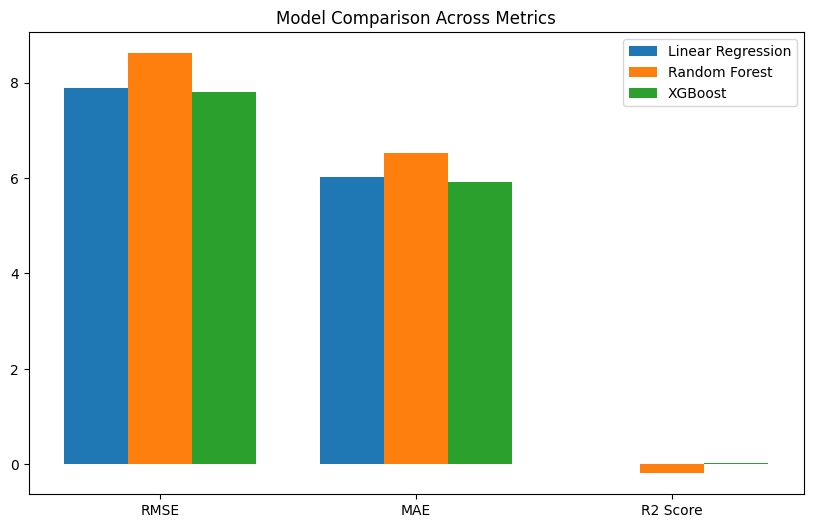

In [50]:
metrics = ['RMSE', 'MAE', 'R2 Score']
models = results_df['Model']

x = np.arange(len(metrics))  # metric positions
width = 0.25  # bar width

plt.figure(figsize=(10,6))

for i, model in enumerate(models):
    plt.bar(x + i*width - width, results_df.loc[i, metrics], width, label=model)

plt.xticks(x, metrics)
plt.legend()
plt.title("Model Comparison Across Metrics")
plt.show()

## Final Conclusion

This project aimed to predict customer order behavior using historical Instacart data by combining transactional and behavioral features. The workflow included data preprocessing, feature engineering, exploratory data analysis (EDA), and model comparison.

---

### 1. Summary of Approach

- Merged order-level and product-level datasets to construct a comprehensive dataset  
- Engineered meaningful features including:
  - Temporal features (day, hour, weekend, peak hour)
  - Behavioral features (user order patterns)
  - Lag features (previous order size)  
- Performed EDA to identify patterns in user behavior and ordering trends  
- Trained and evaluated three models:
  - Linear Regression  
  - Random Forest  
  - XGBoost  

---

### 2. Key Findings from EDA

- Order sizes are skewed, with most users placing small orders  
- User behavior plays a significant role in determining order size  
- Previous order size is a strong predictor of future order size  
- Temporal features alone are weak predictors but improve performance when combined with behavioral features  

---

### 3. Model Performance Summary

| Model              | RMSE   | MAE    | R² Score |
|-------------------|--------|--------|----------|
| Linear Regression | 7.89   | 6.02   | 0.0059   |
| Random Forest     | 8.61   | 6.52   | -0.1841  |
| XGBoost           | 7.80   | 5.92   | 0.0274   |

---

### 4. Model Comparison Insights

- **XGBoost performed the best overall**, achieving the lowest RMSE and MAE  
- **Linear Regression performed comparably**, suggesting limited non-linearity in current features  
- **Random Forest underperformed**, possibly due to:
  - Overfitting tendencies  
  - Lack of sufficient strong features  

- The **R² scores are very low**, indicating that:
  - The current features explain only a small portion of the variance  
  - The dataset lacks strong predictive signals for order size  

---

### 5. Key Observations

- Feature engineering had a noticeable impact, but further improvement is needed  
- The problem is inherently complex due to:
  - High variability in user behavior  
  - Lack of rich contextual features (e.g., pricing, promotions, product types)  
- Removing data leakage resulted in more realistic but lower performance metrics  

---

### 6. Limitations

- No actual timestamp → limits true time-series modeling  
- Limited feature richness → missing business context  
- Weak correlation between individual features and target  

---

### 7. Future Improvements

- Incorporate additional datasets:
  - Product metadata  
  - Pricing and promotions  
- Build more advanced features:
  - User segmentation  
  - Product category preferences  
- Apply advanced models:
  - Gradient boosting tuning  
  - Deep learning (LSTM for sequential patterns)  
- Use cross-validation and hyperparameter tuning  

---

### Final Remark

Although the model performance is modest, the project successfully demonstrates a complete machine learning pipeline, including data preprocessing, feature engineering, EDA, model building, and evaluation. The insights gained highlight the importance of feature quality over model complexity in predictive tasks.

## Actual vs Predicted Comparison (All Models)

This visualization compares the actual order sizes with predictions from:
- Linear Regression
- Random Forest
- XGBoost

Plotting all models together helps evaluate:
- Which model tracks the trend best
- Which model deviates more from actual values
- Overall prediction stability

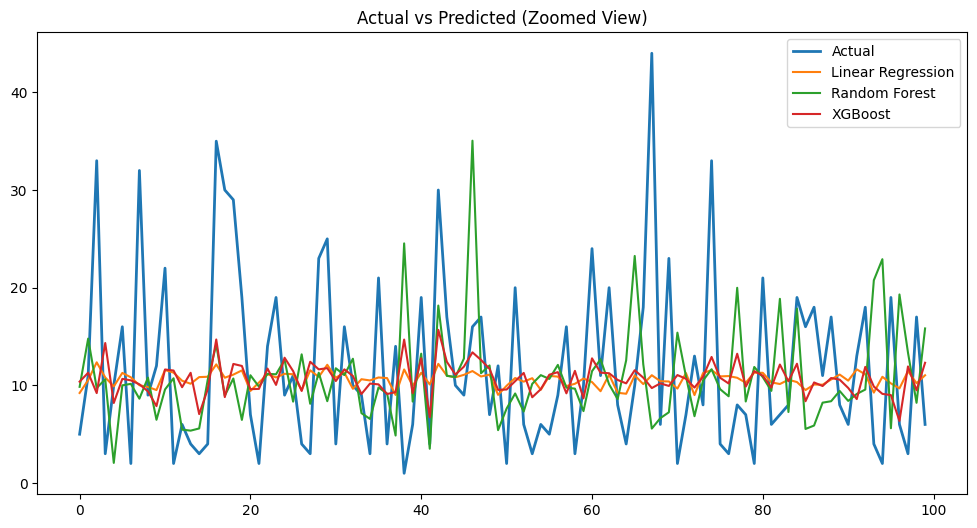

In [52]:
plt.figure(figsize=(12,6))

# Use fewer points for clarity
n = 100

plt.plot(y_test.values[:n], label='Actual', linewidth=2)
plt.plot(y_pred_lr[:n], label='Linear Regression')
plt.plot(y_pred_rf[:n], label='Random Forest')
plt.plot(y_pred_xgb[:n], label='XGBoost')

plt.title("Actual vs Predicted (Zoomed View)")
plt.legend()
plt.show()